In [38]:
# 기본 경로 설정

import os

ROOT_DIR = os.getcwd()
IS_COLAB_MODE = False

# 코랩 모드
if ROOT_DIR == "/content":

    IS_COLAB_MODE = True
    project_num = 13

    from google.colab import drive, userdata
    import subprocess

    drive.mount('/content/drive')

    print("[[ colab ]]")

    if "raw.tar.gz" not in os.listdir():
        # url = f"https://github.com/wonbywondev/ML-DL/releases/download/data-v{project_num}/raw.tar.gz"
        # subprocess.run(["wget", url], check=True)
        
        download_url = f"https://github.com/wonbywondev/ML-DL-data/releases/download/data-v{project_num}/raw.tar.gz"
        command = [
            "wget",
            "--header",
            f"Authorization: token {userdata.get('GITHUB_PAT')}",
            "--header",
            "Accept: application/octet-stream",
            download_url,
            "-O", "raw.tar.gz"]

    print("· 압축 파일 있음")


    DATA_DIR = os.path.join(ROOT_DIR, "data")
    RAW_DIR = os.path.join(DATA_DIR, "raw")
    DRIVE_DIR = os.path.join(ROOT_DIR, "drive")
    SAVE_DIR = os.path.join(DRIVE_DIR, "runs", project_num)

    if not os.path.exists(DATA_DIR):
        os.mkdir(DATA_DIR)

    if not os.path.exists(RAW_DIR):
        subprocess.run(["tar", "-xzvf", "raw.tar.gz", "-C", DATA_DIR], check=True)

    print("· data 압축 해제 완료")

    if not os.path.exists(SAVE_DIR):
        os.mkdir(SAVE_DIR)

# 로컬 모드
else:
    print("[[ local ]]")
    ROOT_DIR = "/".join(ROOT_DIR.split("/")[:-1])
    DATA_DIR = os.path.join(ROOT_DIR, "data")
    RAW_DIR = os.path.join(DATA_DIR, "raw")

[[ local ]]


In [39]:
# 기타 환경 설정
import torch
import matplotlib.pyplot as plt
import gc


# 시각화 관련 설정
if not IS_COLAB_MODE:
    import matplotlib.font_manager as fm
    try:
        plt.rcParams['font.family'] = 'Apple SD Gothic Neo'
    except:
        try:
            plt.rcParams['font.family'] = 'NanumGothic'
        except:
            plt.rcParams['font.family'] = 'AppleGothic'

    plt.rcParams['axes.unicode_minus'] = False
    fm._load_fontmanager(try_read_cache=False)


# 디바이스 설정
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    DEVICE = torch.device("mps") # 맥 GPU
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda") # 윈도우 GPU
else:
    DEVICE = torch.device("cpu") # CPU


# 캐시 지우기 함수 생성
def clean_cache():
    gc.collect()
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        torch.mps.empty_cache()
    elif torch.cuda.is_available():
        torch.cuda.empty_cache()


# MallocStackLogging 에러 출력 방지
os.environ.pop("MallocStackLogging", None)
os.environ.pop("MallocStackLoggingNoCompact", None)
os.environ.pop("DYLD_INSERT_LIBRARIES", None)

In [40]:
from pathlib import Path

raw_json_path_list = [str(path) for path in Path(RAW_DIR).rglob("*.json")]

if IS_COLAB_MODE:
    import unicodedata
    raw_json_path_list = [unicodedata.normalize("NFC", path) for path in raw_json_path_list]

len(raw_json_path_list)

2026

In [41]:
import random
import json

rand_idx = random.randint(1, len(raw_json_path_list))
rand_path = raw_json_path_list[rand_idx - 1]

with open(rand_path, "r", encoding="utf-8") as f:
    sample = json.load(f)

rand_idx = random.randint(1, len(sample))
sample[rand_idx - 1]

{'Index': '270850',
 'RawText': '1.염색이 좀더 편하고, 눈따가움은적어요. 2.와인색상 나쁘지않아요. 3.',
 'Source': '쇼핑몰',
 'Domain': '화장품',
 'MainCategory': '헤어/바디케어',
 'ProductName': 'OO 더** 염색제 세트',
 'ReviewScore': '100',
 'Syllable': '41',
 'Word': '7',
 'RDate': '20210505',
 'GeneralPolarity': '1',
 'Aspects': [{'Aspect': '편의성/활용성',
   'SentimentText': '1.염색이 좀더 편하고,',
   'SentimentWord': '3',
   'SentimentPolarity': '1'},
  {'Aspect': '자극성',
   'SentimentText': '눈따가움은적어요.',
   'SentimentWord': '1',
   'SentimentPolarity': '1'},
  {'Aspect': '색상',
   'SentimentText': '2.와인색상 나쁘지않아요.',
   'SentimentWord': '2',
   'SentimentPolarity': '0'}]}

In [42]:
import json
import pandas as pd

column_list = ["RawText", "Word", "GeneralPolarity"]
all_data = []

for path in raw_json_path_list:
    with open(path, "r", encoding="utf-8") as f:
        dict_list = json.load(f)
        
        for item in dict_list:
            filtered_item = {key: item.get(key) for key in column_list}
            
            all_data.append(filtered_item)

filtered_df = pd.DataFrame(all_data, columns=column_list)

print(f"· 총 데이터: {len(filtered_df)}개")

· 총 데이터: 201616개


In [43]:
print("[결측치]")

for column in column_list:
    if sum(filtered_df[column].isna()) > 0:
        print(f"· 결측 항목: {column}")
        print(f"· {sum(filtered_df[column].isna())}개")
        print(f"· 예시: \n{filtered_df[filtered_df[column].isna()].head(5)}")

        filtered_df = filtered_df.dropna()
        print(f"\n· 제거 후 데이터: {len(filtered_df)}개")

filtered_df["GeneralPolarity"] = filtered_df["GeneralPolarity"].astype(int)

[결측치]
· 결측 항목: GeneralPolarity
· 17091개
· 예시: 
                                              RawText Word GeneralPolarity
13  귀에서 자꾸 빠져요.귀에 꼽는재 질이 미끄러운 재질이라 작은 소품이지만 재질만 바꾸...   89            None
43  아이를 출산한 기념으로 TV를 바꿨습니다. 그전에 쓰던 TV가 꽤나 무거워서 떨어지...   79            None
44  화면에 노이즈가 생깁니다. 저희 가족 중에 아무도 TV 화면을 건드리거나 하지 않았...   85            None
55  이번에 이사하면서 우리 따님께서 방에 TV가 있으면 좋겠다고 하여, 방에서 사용할 ...   73            None
93  기존에 사용하던 무선이어폰이 오래되어서 배터리가 광탈하는 바람에 새로운 상품이 필요...   68            None

· 제거 후 데이터: 184525개


In [44]:
print("[중복치]")

if sum(filtered_df["RawText"].duplicated()) > 0:
    print(filtered_df[filtered_df["RawText"].duplicated()].head(5))

else:
    print("중복치 없음")

[중복치]
중복치 없음


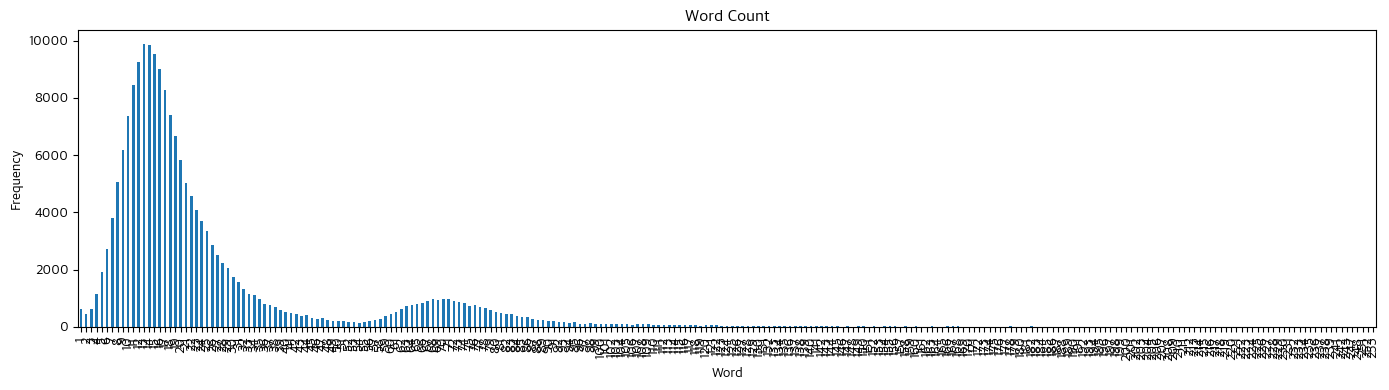

In [45]:
filtered_df["Word"] = filtered_df["Word"].astype(int)

data = filtered_df["Word"].value_counts().sort_index()

plt.figure(figsize=(14,4))
data.plot(kind="bar")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.title("Word Count")
plt.tight_layout()
plt.show()

In [46]:
print("[극단치]")

filtered_df = filtered_df[filtered_df["Word"] <= 50]

print(f"· 제거 후 데이터: {len(filtered_df)}개")

[극단치]
· 제거 후 데이터: 158825개


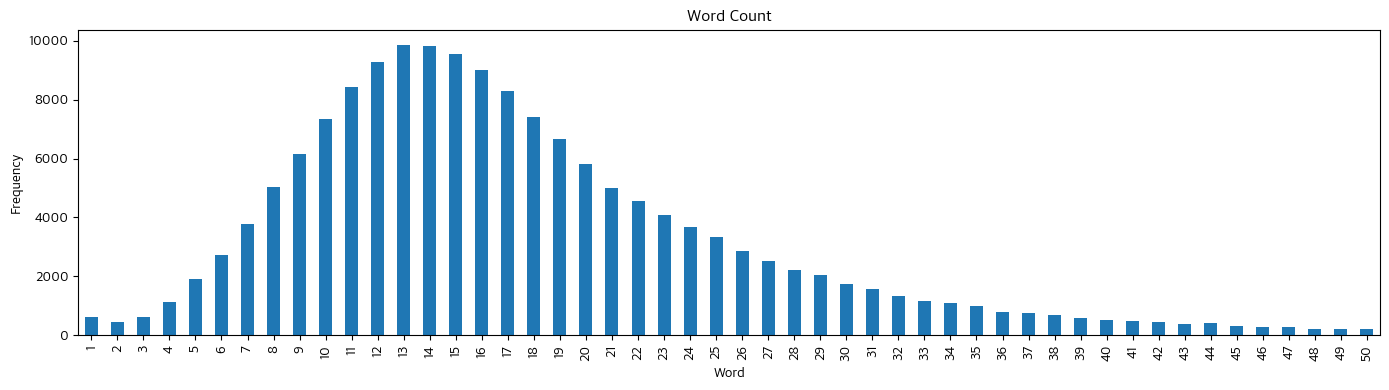

In [47]:
data = filtered_df["Word"].value_counts().sort_index()

plt.figure(figsize=(14,4))
data.plot(kind="bar")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.title("Word Count")
plt.tight_layout()
plt.show()

filtered_df = filtered_df.drop("Word", axis=1)

In [48]:
filtered_df = filtered_df.reset_index().drop("index", axis=1)

filtered_df["GeneralPolarity"] += 1

filtered_df["GeneralPolarity"].value_counts()

GeneralPolarity
2    100348
1     33299
0     25178
Name: count, dtype: int64

---

In [49]:
RAW_TEXT_LIST = list(filtered_df["RawText"])
CLASS_LIST = list(filtered_df["GeneralPolarity"])

In [50]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "tabularisai/multilingual-sentiment-analysis"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, 
    num_labels=3, 
    ignore_mismatched_sizes=True
    )

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at tabularisai/multilingual-sentiment-analysis and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([5]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([5, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [61]:
from torch.utils.data import Dataset

class BasicDataset(Dataset):
    def __init__(self, tokenizer):
        self.X_list = RAW_TEXT_LIST
        self.y_list = CLASS_LIST
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.X_list)
    
    def __getitem__(self, index):
        text = self.X_list[index]
        
        X = self.tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)
        y = self.y_list[index]

        return {
            "input_ids": X["input_ids"],
            "attention_mask": X["attention_mask"],
            "label": y
            }
    
SIMPLE_DATASET = BasicDataset(tokenizer=tokenizer)

In [62]:
SIMPLE_DATASET[2]

{'input_ids': tensor([[   101,   9022,  10739,  24891,  11287,   9117,  12692,  48599,  45593,
            8946, 118708,  17594,   9654,  27023,  26737,  48549,   9685,  16985,
           48549,    119,    119,    119,   9706,  33305,  35465,  10530,   8908,
          100372,  62484,   9246,  10739,  20308,  11018,   9022,  10739,  24891,
           11287,   9553,  40311,  47058,   9117,  26737,  12424,   9519, 119070,
          119172,  77884,  48549,    119,    119,    119,    119,   9638,  35465,
           15303,  99706,  42337,  11489,   9511,  11018,   8870,  11882,   9379,
          119082,  11102,    100,   9519,  16323,   9248,  52560,  12605,  30873,
           21614,   9924,  10739,  10530,  48549,    106,   9952,  78123,  80174,
           12092,  47058,   9913,  12508,  12508,   9523,  16985,  12424,   9711,
           11489,   9405,  24974,  22440,   9131,   9256,  16985,  12424,   9685,
          119081,  48345,    119,   9597,  27506,  10739,   9993,  26737,  12453,
   

In [63]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader, WeightedRandomSampler

train_indices, tmp_indices = train_test_split(
    list(range(len(SIMPLE_DATASET))),
    test_size=0.2,
    stratify=CLASS_LIST
    )

val_indices, test_indices = train_test_split(
    list(range(len(tmp_indices))),
    test_size=0.5,
    stratify=[CLASS_LIST[idx] for idx in tmp_indices]
    )

simple_train_subset = Subset(SIMPLE_DATASET, train_indices)
simple_val_subset = Subset(SIMPLE_DATASET, val_indices)
simple_test_subset = Subset(SIMPLE_DATASET, test_indices)

print(f"[분할 결과]")
print(f"· 기존 학습 데이터: {len(SIMPLE_DATASET)}개")
print(f"· 분할 후 학습 데이터: {len(train_indices)}개 ({len(train_indices) / len(SIMPLE_DATASET) * 100:.2f}%)")
print(f"· 분할 후 검증 데이터: {len(val_indices)}개 ({len(val_indices) / len(SIMPLE_DATASET) * 100:.2f}%)")
print(f"· 분할 후 테스트 데이터: {len(test_indices)}개 ({len(test_indices) / len(SIMPLE_DATASET) * 100:.2f}%)")

[분할 결과]
· 기존 학습 데이터: 158825개
· 분할 후 학습 데이터: 127060개 (80.00%)
· 분할 후 검증 데이터: 15882개 (10.00%)
· 분할 후 테스트 데이터: 15883개 (10.00%)


In [ ]:
# 샘플러 설정
labels = torch.tensor([CLASS_LIST[idx] for idx in train_indices])

class_counts = torch.bincount(labels)
class_weights = len(train_indices) / class_counts.float()
samples_weights = class_weights[labels]

simple_sampler = WeightedRandomSampler(
    weights=samples_weights,
    num_samples=len(samples_weights),
    replacement=True)

print(f"[학습 데이터]")
print(f"· 부정 리뷰: {class_counts[0]}개 ({class_counts[0] / len(labels) * 100:.2f}%)")
print(f"· 중립 리뷰: {class_counts[1]}개 ({class_counts[1] / len(labels) * 100:.2f}%)")
print(f"· 긍정 리뷰: {class_counts[2]}개 ({class_counts[2] / len(labels) * 100:.2f}%)")

print(f"\n[샘플러 가중치]")
print(f"· 부정 클래스: {class_weights[0]:.4f}")
print(f"· 중립 클래스: {class_weights[1]:.4f}")
print(f"· 긍정 클래스: {class_weights[2]:.4f}")

# 채널별 데이터 로더 설정
SIMPLE_TRAIN_LOADER = DataLoader(simple_train_subset, batch_size=64, sampler=simple_sampler, shuffle=False, num_workers=4)
SIMPLE_VAL_LOADER = DataLoader(simple_val_subset, batch_size=64, shuffle=False, num_workers=4)
SIMPLE_TEST_LOADER = DataLoader(simple_test_subset, batch_size=64, shuffle=False, num_workers=4)

[학습 데이터]
· 부정 리뷰: 20143개 (15.85%)
· 중립 리뷰: 26639개 (20.97%)
· 긍정 리뷰: 80278개 (63.18%)

[샘플러 가중치]
· 부정 클래스: 6.3079
· 중립 클래스: 4.7697
· 긍정 클래스: 1.5827


In [78]:
def predict_sentiment(texts):
    inputs = tokenizer(texts, return_tensors="pt", truncation=True, padding=True, max_length=512)

    with torch.no_grad():
        outputs = model(**inputs)
    
    probabilities = torch.nn.functional.softmax(outputs.logits, dim=-1)
    sentiment_map = {0: "부정", 1: "중립", 2: "긍정"}

    return [sentiment_map[p] for p in torch.argmax(probabilities, dim=-1).tolist()]

# 샘플 출력
sample_Xs = [RAW_TEXT_LIST[idx] for idx in train_indices[:5]]
sample_ys = [CLASS_LIST[idx] for idx in train_indices[:5]]

for X, y_pred in zip(sample_Xs, predict_sentiment(sample_Xs)):
    print(f"Text: {X}\nSentiment: {y_pred}\n")

Text: 색상이 예쁘네요 하지만 롱패딩이라하기엔 좀 짧아요 제가 갖고있는 기존 롱패딩보다 평균 10센치는 더 짧아요 전 키가커서 좀 애매하게 되었어요
Sentiment: 부정

Text: 가볍고 편해서 나들이갈때도 신고 마트갈때도 신고 합니다
Sentiment: 부정

Text: 저음 사운드가 워낙 풍부해서 리듬타기 최적입니다!! 설정 하는 법도 간단해서 좋아요~
Sentiment: 긍정

Text: 별이 아깝네요 발이 아파 신을수가 없어요 230이면 넉넉한 크기로 구매 했는데 마감처리? 가 잘못 되었는지 쓰레기통에 버려야겠어요.  발등이 아파 신을수가 없어요 실망이네요
Sentiment: 부정

Text: 이건 워낙 좋아서 비싸도 계속 사용하고 있는 제품이에요. 가격만 조금 저렴해졌으면 좋겠습니다. 기름기 잠재워주고 뽀송뽀송해져서 좋습니다. 그렇다고 엄청 건조해지는건 아니고 말 그대로 뽀송뽀송해집니다. 이거로 덮고 마스크 쓰면 화장이 좀 덜 묻어나는 느낌입니다.
Sentiment: 부정



In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

for epoch in range(3):
    model.train()
    for batch in SIMPLE_TRAIN_LOADER:
        optimizer.zero_grad()
        
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        
        loss.backward()
        optimizer.step()
        
    print(f"Epoch {epoch+1} completed. Loss: {loss.item()}")

In [ ]:
import torch.optim as optim

# 모델·옵티마이저 설정
params_to_update = []
for param in model.parameters():
    param.requires_grad = True

# 디바이스
model = model.to(DEVICE)

# 옵티마이저 할당
optimizer = optim.AdamW(model.parameters(), lr=2e-5)

In [ ]:
# Full-fine-tuning

clean_cache()

RESULT_DF = pd.read_pickle("./checkpoints/results_df.pkl")

num_epochs = 5

mode = "Ch_3_Full"
model, optimizer, device = ch_3_full_model, ch_3_full_optim, ch_3_full_device
model, optimizer, start_epoch = load_checkpoint(mode, model, optimizer)

print(f"start_epoch: {start_epoch+1}")


for epoch in range(start_epoch, num_epochs):

    # 훈련
    train_result_list = train_model(dataloader=CH_3_TRAIN_LOADER, model=model, optimizer=optimizer, device=device)
    save_result_df(mode, "Train", epoch, train_result_list)

    # 검증
    val_result_list = eval_model(dataloader=CH_3_VAL_LOADER, model=model, device=device)
    save_result_df(mode, "Val", epoch, val_result_list)

    # 테스트
    test_result_list = eval_model(dataloader=CH_3_TEST_LOADER, model=model, device=device)
    save_result_df(mode, "Test", epoch, test_result_list)

    # 체크포인트 저장: 테스트 데이터까지 RESULT_DF에 기록된 후 진행.
    save_checkpoint(mode, epoch+1, model, optimizer, train_result_list[0])

clean_cache()

In [ ]:
# # 텔레그램
# import requests
# from dotenv import load_dotenv
# import os

# def send_telegram_message(message):
#     if IS_COLAB_MODE:
#         token = userdata("TELEGRAM_BOT_TOKEN")
#         chat_id = userdata("TELEGRAM_CHAT_ID")
    
#     else:
#         load_dotenv(dotenv_path=os.path.join(ROOT_DIR, ".env"))
        
#         token = os.getenv("TELEGRAM_BOT_TOKEN")
#         chat_id = os.getenv("TELEGRAM_CHAT_ID")

#     url = f'https://api.telegram.org/bot{token}/sendMessage'
#     payload = {
#         'chat_id': chat_id,
#         'text': message
#         }
    
#     try:
#         requests.post(url, json=payload)
#     except Exception as e:
#         print(f"Failed to send message: {e}")

# message = "학습 완료"
# send_telegram_message(message)